In [1]:
import numpy as np
import pandas as pd
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.chunking_data import ChunkLoader

In [2]:
config = read_config(
   '/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/config_n2o.yaml')
analyze_year=True
# years=[2007,2008,2009,2010,2011,2012,2013,2014,2015]
years = [year for year in range(2007, 2017)]
glac_threshold=0.4


In [3]:
# Set up analysis dataframe
dataset = ChunkLoader(years,config=config,load_init_chunk=False)

Cloud_fps: {2007: '/wolke_scratch/dnikolo/Final_results/2007_all.parquet', 2008: '/wolke_scratch/dnikolo/Final_results/2008_all.parquet', 2009: '/wolke_scratch/dnikolo/Final_results/2009_all.parquet', 2010: '/wolke_scratch/dnikolo/Final_results/2010_all.parquet', 2011: '/wolke_scratch/dnikolo/Final_results/2011_all.parquet', 2012: '/wolke_scratch/dnikolo/Final_results/2012_all.parquet', 2013: '/wolke_scratch/dnikolo/Final_results/2013_all.parquet', 2014: '/wolke_scratch/dnikolo/Final_results/2014_all.parquet', 2015: '/wolke_scratch/dnikolo/Final_results/2015_all.parquet', 2016: '/wolke_scratch/dnikolo/Final_results/2016_all.parquet'}


In [4]:
# Set up analysis dataframe
dataset = ChunkLoader(years,config=config)

Cloud_fps: {2007: '/wolke_scratch/dnikolo/Final_results/2007_all.parquet', 2008: '/wolke_scratch/dnikolo/Final_results/2008_all.parquet', 2009: '/wolke_scratch/dnikolo/Final_results/2009_all.parquet', 2010: '/wolke_scratch/dnikolo/Final_results/2010_all.parquet', 2011: '/wolke_scratch/dnikolo/Final_results/2011_all.parquet', 2012: '/wolke_scratch/dnikolo/Final_results/2012_all.parquet', 2013: '/wolke_scratch/dnikolo/Final_results/2013_all.parquet', 2014: '/wolke_scratch/dnikolo/Final_results/2014_all.parquet', 2015: '/wolke_scratch/dnikolo/Final_results/2015_all.parquet', 2016: '/wolke_scratch/dnikolo/Final_results/2016_all.parquet'}


In [5]:
def extract_glac_df(dfs):
    _ , glac_df , _ = dfs
    return glac_df
def extract_glac_df_all(dataset):
    return list(dataset.execute_analysis(extract_glac_df,load_clouds=False,load_glac=True))

In [6]:
glac_df_list = extract_glac_df_all(dataset)

Loading years: 100%|██████████| 10/10 [00:19<00:00,  1.98s/year]


In [7]:
glac_df_list["Peak IF"]

TypeError: list indices must be integers or slices, not str

In [ ]:
(combined_glac_df["Peak IF"]>0.9).value_counts(normalize =True)

In [9]:
combined_glac_df = pd.concat(glac_df_list)

## Glaciation event analysis

In [10]:
combined_glac_df.loc[:,"Peak IF"]=combined_glac_df.apply(lambda x: x["ice_frac_hist"][x["Glac_peak_ind"]], axis =1)
combined_glac_df.loc[:,"Final IF"]=combined_glac_df.apply(lambda x: x["ice_frac_hist"][-1], axis =1)

In [15]:
((combined_glac_df['avg_lat']<30) & (combined_glac_df['avg_lat']>-30)).value_counts(normalize=True)

avg_lat
False    1.0
Name: proportion, dtype: float64

In [11]:
(combined_glac_df["Peak IF"]==1).value_counts(normalize =True)

Peak IF
False    0.952749
True     0.047251
Name: proportion, dtype: float64

In [23]:
combined_glac_df.keys()

Index(['Cloud_ID', 'Time [m]', 'Magnitude', 'Glac_start_ind', 'Glac_peak_ind',
       'Linear', 'line_rmse', 'Rate_arr', 'Mean_glac_rate',
       'Glaciation time [h]', 'tracknumber', 'is_large_pix_cloud',
       'is_cot_valid_cloud', 'is_ctp_valid_cloud', 'is_liq', 'is_mix',
       'is_ice', 'max_water_frac', 'max_ice_fraction', 'avg_size[km]',
       'max_size[km]', 'min_size[km]', 'avg_size[px]', 'max_size[px]',
       'min_size[px]', 'track_start_time', 'track_length', 'avg_cot',
       'avg_ctp', 'avg_ctt', 'glaciation_start_time', 'glaciation_end_time',
       'avg_lat', 'avg_lon', 'start_ice_fraction', 'end_ice_fraction',
       'ice_frac_hist', 'cot_hist', 'cot_std_hist', 'cot_nan_frac_hist',
       'ctp_hist', 'ctp_std_hist', 'ctp_nan_frac_hist', 'ctt_hist',
       'ctt_std_hist', 'lat_hist', 'lon_hist', 'size_hist_km', 'min_temp',
       'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]', 'Radius [km]',
       'track_end_time', 'Level', 'Optical Thickness', 'Cloud type', 'Seaso

In [24]:
combined_glac_df.iloc[0].cot_hist

array([       nan, 0.09090868, 0.16340509, 0.10735771], dtype=float32)

In [25]:
(combined_glac_df["Peak IF"]<0.9).value_counts(normalize=True)

Peak IF
True     0.832272
False    0.167728
Name: proportion, dtype: float64

In [16]:
def calc_delta_cot(x):
    if np.isnan(x.cot_hist).any():
        return -1000
    else:
        return x["cot_hist"][:x["Glac_peak_ind"]].mean()-x["cot_hist"][x["Glac_peak_ind"]+1:].mean() if (x["Glac_peak_ind"]<len(x["cot_hist"])-1) else -1000

In [15]:
combined_glac_df.apply(lambda x: x["Glac_peak_ind"]<len(x["cot_hist"])-1,axis=1).value_counts(normalize=True)

True     0.596251
False    0.403749
Name: proportion, dtype: float64

In [17]:
combined_glac_df.loc[:,"delta_cot"] = combined_glac_df.apply(calc_delta_cot , axis =1)

In [28]:
combined_glac_df[combined_glac_df.delta_cot!=-1000].cot_hist

47        [0.54378223, 0.482874, 0.4315304, 0.40247944, ...
117       [14.026864, 12.347066, 11.0584, 10.683466, 15....
118       [4.8433766, 3.5077798, 3.3012738, 3.0779274, 2...
130       [1.8509067, 1.4089487, 1.4545606, 1.2880602, 1...
138           [1.6948805, 1.7262961, 0.97308505, 0.8350727]
                                ...                        
121661    [12.800195, 12.521697, 8.861913, 3.6705697, 4....
121664    [7.5964913, 6.4735274, 7.2491474, 7.100924, 5....
121666    [14.68813, 9.906285, 7.797371, 5.980577, 6.913...
121669    [7.1311045, 8.034348, 8.972797, 7.7685676, 5.7...
121673    [11.8305645, 11.542838, 11.864046, 12.335351, ...
Name: cot_hist, Length: 169440, dtype: object

In [19]:
(combined_glac_df.delta_cot==-1000).value_counts(normalize=True)

delta_cot
True     0.818158
False    0.181842
Name: proportion, dtype: float64

In [20]:
import numpy as np
import pandas as pd

def diagnose_row(x):
    # Safely coerce to a 1D float array; if it fails, mark non-numeric
    non_numeric = False
    try:
        arr = np.asarray(x.get("cot_hist", []), dtype=float)
    except Exception:
        arr = np.array([], dtype=float)
        non_numeric = True

    n = arr.size
    g = x.get("Glac_peak_ind", -1)
    try:
        g = int(g)
    except Exception:
        g = -1

    # Edge/emptiness without slicing
    left_empty  = g <= 0
    right_empty = (n == 0) or (g >= n-1)
    g_out_of_bounds = (g < 0) or (g >= n)

    has_nan = np.isnan(arr).any() if n > 0 else False

    # Only compute means if slices are non-empty
    if not left_empty:
        left_mean = np.nanmean(arr[:g])
        left_mean_zero = np.isfinite(left_mean) and (left_mean == 0.0)
    else:
        left_mean = np.nan
        left_mean_zero = False

    if not right_empty:
        right_mean = np.nanmean(arr[g+1:])
        right_mean_zero = np.isfinite(right_mean) and (right_mean == 0.0)
    else:
        right_mean = np.nan
        right_mean_zero = False

    # Your threshold condition
    fails_threshold = False
    try:
        thresh = x.get("track_length") / pd.Timedelta(minutes=15)
        if not (g < thresh):
            fails_threshold = True
    except Exception:
        # If track_length is bad/missing, flag it as failing threshold
        fails_threshold = True

    will_warn_mean_empty_slice = left_empty or right_empty

    reasons = []
    if non_numeric: reasons.append("cot_hist_non_numeric")
    if n == 0: reasons.append("cot_hist_empty")
    if g_out_of_bounds: reasons.append("Glac_peak_ind_out_of_bounds")
    if left_empty: reasons.append("left_slice_empty")
    if right_empty: reasons.append("right_slice_empty")
    if has_nan: reasons.append("cot_hist_has_NaN")
    if left_mean_zero: reasons.append("left_mean_zero")
    if right_mean_zero: reasons.append("right_mean_zero")
    if fails_threshold: reasons.append("fails_track_length_threshold")

    return pd.Series({
        "will_warn_mean_empty_slice": will_warn_mean_empty_slice,
        "cot_hist_has_NaN": has_nan,
        "cot_hist_non_numeric": non_numeric,
        "cot_hist_len": n,
        "Glac_peak_ind": g,
        "g_out_of_bounds": g_out_of_bounds,
        "left_slice_empty": left_empty,
        "right_slice_empty": right_empty,
        "left_mean": left_mean,
        "right_mean": right_mean,
        "left_mean_zero": left_mean_zero,
        "right_mean_zero": right_mean_zero,
        "fails_threshold": fails_threshold,
        "reasons": ", ".join(reasons)
    })

# Run diagnostics
flags = combined_glac_df.apply(diagnose_row, axis=1)

# Rows that are likely causing your warnings
problem_mask = (
    flags["will_warn_mean_empty_slice"] |
    flags["cot_hist_non_numeric"] |
    flags["g_out_of_bounds"]
)

problematic_rows = pd.concat([combined_glac_df, flags], axis=1).loc[problem_mask]

# Inspect a quick summary and the first few problematic entries
print("Counts of issues:\n", flags.drop(columns=["left_mean","right_mean","reasons"]).sum(numeric_only=True))
print("\nFirst 20 problematic rows with reasons:\n")
display_cols = ["Glac_peak_ind","track_length","cot_hist","reasons"]
print(problematic_rows[display_cols].head(20).to_string(index=True))


KeyboardInterrupt: 

In [22]:
def calc_delta_cot_frac(x):
    if np.isnan(x.cot_hist).any():
        return -1000
    elif (x["Glac_peak_ind"]<x["cot_hist"].size-1):
        if (x["cot_hist"][x["Glac_peak_ind"]+1:].mean()!=0) and (x["cot_hist"][:x["Glac_peak_ind"]].mean()!=0):
            return x["cot_hist"][x["Glac_peak_ind"]+1:].mean()/x["cot_hist"][:x["Glac_peak_ind"]].mean()-1  
        else:
            return -1000
    else:
        return -1000
combined_glac_df.loc[:,"delta_cot_frac"] = combined_glac_df.apply(calc_delta_cot_frac , axis =1)

In [23]:
print(combined_glac_df[combined_glac_df["delta_cot"]!=-1000]["delta_cot"].median())
print(combined_glac_df[(combined_glac_df["delta_cot_frac"]!=-1000) & (combined_glac_df["delta_cot_frac"]<9) ]["delta_cot_frac"].describe())

1.413938283920288
count    168467.000000
mean          0.074780
std           1.010348
min          -0.999994
25%          -0.490708
50%          -0.183091
75%           0.260077
max           8.989748
Name: delta_cot_frac, dtype: float64


In [25]:
(combined_glac_df[combined_glac_df["delta_cot_frac"] != -1000]["delta_cot_frac"]>9).value_counts(normalize=True)

delta_cot_frac
False    0.99535
True     0.00465
Name: proportion, dtype: float64

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='delta_cot_frac', ylabel='Count'>

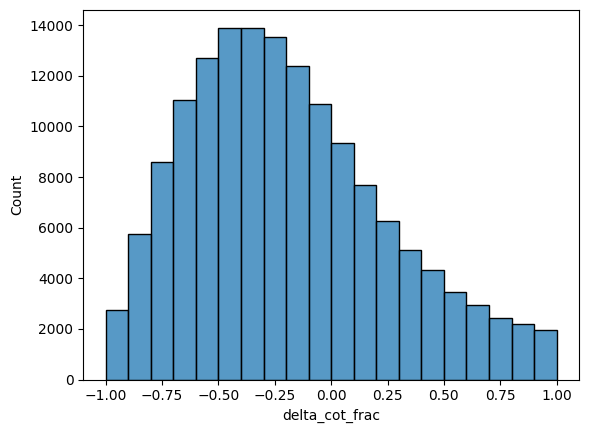

In [26]:
import seaborn as sns
# Define bins from -1 to 1 with 0.1 step
bins = np.arange(-1, 1.1, 0.1)

# Filter and plot
sns.histplot(combined_glac_df[combined_glac_df["delta_cot_frac"] != -1000]["delta_cot_frac"], bins=bins)

In [33]:
search_rad=1
search_rad-=1
calc_mean_diff_pre_post_glac_rad  = lambda x: np.array([x["ice_frac_hist"][x["Glac_peak_ind"]-i]-x["ice_frac_hist"][x["Glac_peak_ind"]+i] for i in range(1,2+search_rad)]).mean() if (x["Glac_peak_ind"]<len(x["cot_hist"])-1-search_rad) else -100
cloud = combined_glac_df.iloc[3]
calc_mean_diff_pre_post_glac  = lambda x: x["ice_frac_hist"][:x["Glac_peak_ind"]].mean()-x["ice_frac_hist"][x["Glac_peak_ind"]+1:].mean() if (x["Glac_peak_ind"]<len(x["cot_hist"])-1) else -100
calc_post_glac_drop_rad_1  = lambda x: np.array([x["ice_frac_hist"][x["Glac_peak_ind"]]-x["ice_frac_hist"][x["Glac_peak_ind"]+i] for i in range(1,2+search_rad)]).mean() if (x["Glac_peak_ind"]<len(x["cot_hist"])-1-search_rad) else -100
calc_post_glac_drop  = lambda x: x["ice_frac_hist"][x["Glac_peak_ind"]]-x["ice_frac_hist"][x["Glac_peak_ind"]+1:].mean() if (x["Glac_peak_ind"]<len(x["cot_hist"])-1) else -100

print(cloud["ice_frac_hist"])
print(cloud["ice_frac_hist"][cloud["Glac_peak_ind"]])
print(calc_post_glac_drop_rad_1(cloud))
print(calc_post_glac_drop(cloud))

[0.         0.0093201  0.41271797 0.12513566 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.02776149]
0.41271797
0.2875823
0.40095666


In [34]:
combined_glac_df.loc[:,"Pre_post_glac_dif_rad_1"]=combined_glac_df.apply(calc_mean_diff_pre_post_glac_rad , axis =1)
combined_glac_df.loc[:,"Pre_post_glac_dif"]=combined_glac_df.apply(calc_mean_diff_pre_post_glac , axis =1)
combined_glac_df.loc[:,"Post_glac_drop"]=combined_glac_df.apply(calc_post_glac_drop , axis =1)
combined_glac_df.loc[:,"Post_glac_drop_rad_1"]=combined_glac_df.apply(calc_post_glac_drop_rad_1 , axis =1)

In [35]:
print(combined_glac_df[combined_glac_df["Pre_post_glac_dif_rad_1"]!=-100]["Pre_post_glac_dif_rad_1"].median())
print(combined_glac_df[combined_glac_df["Pre_post_glac_dif"]!=-100]["Pre_post_glac_dif"].median())
print(combined_glac_df[combined_glac_df["Post_glac_drop"]!=-100]["Post_glac_drop"].median())
print(combined_glac_df[combined_glac_df["Post_glac_drop_rad_1"]!=-100]["Post_glac_drop_rad_1"].median())

-0.03193056583404541
-0.134397953748703
0.22764384746551514
0.1298002004623413


In [ ]:
(combined_glac_df["Pre_post_glac_dif"]==0).value_counts(normalize=True)

Pre_post_glac_dif
False    0.999805
True     0.000195
Name: proportion, dtype: float64

In [36]:
(combined_glac_df["Final IF"]==combined_glac_df.loc[:,"Peak IF"]).value_counts(normalize=True)

False    0.586633
True     0.413367
Name: proportion, dtype: float64

In [37]:
(combined_glac_df["Glac_peak_ind"]==combined_glac_df["track_length"]/pd.Timedelta(minutes=15)).value_counts(normalize=True)

False    0.596281
True     0.403719
Name: proportion, dtype: float64